# Session 2 Task – Linear Regression Using Gradient Descent

In this task I build a linear regression model **from scratch** (no scikit-learn) and train it with
**Gradient Descent**, following the equations from the lecture slides
(*Session 1 – Linear Regression*, slides 13–21, and *Session 1 (Machine Learning)*, slides 18–25).

**Problem:** predict the price of a house from its size.

| Name in the task | Symbol in the slides | Meaning |
|---|---|---|
| `theta_0` | $a_0$ | intercept (bias) |
| `theta_1` | $a_1$ | slope (weight) |
| `learning_rate` | $\alpha$ | step size |
| `n_iters` | epochs | how many times the update is repeated |

The model is the straight line $\hat{y} = \theta_0 + \theta_1 \, x$ and the goal is to find the
$\theta_0, \theta_1$ that make the error between $\hat{y}$ and the real $y$ as small as possible.

## The `LinearRegressionGD` class

The task says the class is "provided", so here I write it myself following exactly the update rules
from slide 19 of the Linear Regression lecture:

$$\hat{y}_i = \theta_0 + \theta_1 x_i$$

$$J = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2 \;\;\text{(MSE)}
\qquad\qquad SSE = \sum_{i=1}^{n}(\hat{y}_i - y_i)^2 = n \cdot J$$

$$D_{\theta_0} = \frac{2}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)
\qquad\qquad D_{\theta_1} = \frac{2}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)\,x_i$$

$$\theta_0 \leftarrow \theta_0 - \alpha\,D_{\theta_0} \qquad\qquad \theta_1 \leftarrow \theta_1 - \alpha\,D_{\theta_1}$$

Every iteration the class stores the **SSE** (sum of squared errors) so I can plot it later with
`plot_training()`. I also added `mse()` (bonus task 1) and a small safety check that stops the loop
if the SSE becomes infinite, so a bad learning rate does not fill the notebook with warnings.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class LinearRegressionGD:
    """Simple linear regression (one feature) trained with batch Gradient Descent.

    Model    : y_pred = theta_0 + theta_1 * x
    Cost     : SSE = sum((y_pred - y)^2)          (stored every iteration in sse_history)
    Gradients: d_theta_0 = (2/n) * sum(y_pred - y)
               d_theta_1 = (2/n) * sum((y_pred - y) * x)
    Update   : theta = theta - learning_rate * gradient
    """

    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0        # intercept (a0 in the slides)
        self.theta_1 = 0.0        # slope     (a1 in the slides)
        self.sse_history = []     # SSE at every iteration

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self.theta_0 + self.theta_1 * X

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n = len(X)
        self.theta_0, self.theta_1 = 0.0, 0.0
        self.sse_history = []

        for i in range(self.n_iters):
            y_pred = self.predict(X)
            error = y_pred - y                       # (predict_i - y_i)
            with np.errstate(over="ignore"):         # a diverging run overflows; the check below handles it
                sse = np.sum(error ** 2)
            self.sse_history.append(sse)

            if not np.isfinite(sse):                 # safety: stop if training blew up
                print(f"Training diverged at iteration {i + 1}: SSE is no longer a finite number.")
                break

            d_theta_0 = (2 / n) * np.sum(error)      # D_a0 in the slides
            d_theta_1 = (2 / n) * np.sum(error * X)  # D_a1 in the slides

            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1
        return self

    def mse(self, X, y):
        """Bonus: Mean Squared Error of the current parameters."""
        y = np.asarray(y, dtype=float)
        return np.mean((self.predict(X) - y) ** 2)

    def plot_training(self, X, y):
        """Left: SSE over iterations. Right: regression line with the data points."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        sse = np.array(self.sse_history)
        ax1.plot(np.arange(1, len(sse) + 1), sse, color="tab:red")
        finite = sse[np.isfinite(sse)]
        if len(finite) and finite.max() / max(finite.min(), 1e-12) > 1e4:
            ax1.set_yscale("log")              # log scale when SSE spans many orders of magnitude
        ax1.set_xlabel("Iteration")
        ax1.set_ylabel("SSE")
        ax1.set_title(f"SSE over iterations (lr = {self.learning_rate})")
        ax1.grid(alpha=0.3)

        ax2.scatter(X, y, color="tab:blue", zorder=3, label="data points")
        pad_x = 0.1 * (X.max() - X.min())
        x_line = np.linspace(X.min() - pad_x, X.max() + pad_x, 100)
        sign = "+" if self.theta_1 >= 0 else "-"
        ax2.plot(x_line, self.predict(x_line), color="tab:red",
                 label=f"y = {self.theta_0:.4g} {sign} {abs(self.theta_1):.4g} x")
        pad = 0.2 * (y.max() - y.min())
        ax2.set_ylim(y.min() - pad, y.max() + pad)  # keep the data visible even if the line is far away
        ax2.set_xlabel("X")
        ax2.set_ylabel("y")
        ax2.set_title("Regression line")
        ax2.legend()
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

## 1. Load & understand the data

**What X and y represent**

- `X` = the **size of the house in m²**. This is the *input / feature / independent variable* – the thing we know.
- `y` = the **price of the house in thousands** (150 means 150,000). This is the *target / label / dependent variable* – the thing we want to predict.

Each pair `(X[i], y[i])` is one house whose answer we already know, so this is **supervised learning**,
and because the price is a continuous number (not a category) it is a **regression** problem
(Linear Regression lecture, slides 10–11).

Looking at the numbers: every time the size goes up by 10 m² the price goes up by 30, and
$150 = 3 \times 50$, $180 = 3 \times 60$, … so the data lies exactly on the line $y = 3x$.
The perfect answer would be $\theta_0 = 0$ and $\theta_1 = 3$. That gives me something to compare the trained model against.

In [3]:
X = np.array([50, 60, 70, 80, 90], dtype=float)         # house size (m²)
y = np.array([150, 180, 210, 240, 270], dtype=float)    # house price (thousands)

print("X:", X, "| type:", type(X).__name__, "| shape:", X.shape)
print("y:", y, "| type:", type(y).__name__, "| shape:", y.shape)
print("price / size for every house:", y / X)

X: [50. 60. 70. 80. 90.] | type: ndarray | shape: (5,)
y: [150. 180. 210. 240. 270.] | type: ndarray | shape: (5,)
price / size for every house: [3. 3. 3. 3. 3.]


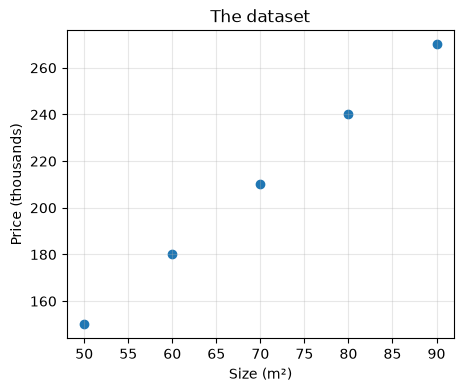

In [4]:
plt.figure(figsize=(5, 4))
plt.scatter(X, y, color="tab:blue")
plt.xlabel("Size (m²)")
plt.ylabel("Price (thousands)")
plt.title("The dataset")
plt.grid(alpha=0.3)
plt.show()

## 2. Create and train the model

Settings from the task: `learning_rate = 0.001` and `n_iters = 100`.

In [5]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(X, y)

print(f"theta_0 (intercept)  = {model.theta_0}")
print(f"theta_1 (slope)      = {model.theta_1}")
print(f"SSE at iteration 1   = {model.sse_history[0]:.4g}")
print(f"SSE at iteration 100 = {model.sse_history[-1]:.4g}")

theta_0 (intercept)  = -1.0055957901462392e+95
theta_1 (slope)      = -7.326427288635144e+96
SSE at iteration 1   = 2.295e+05
SSE at iteration 100 = 1.617e+196


**Question: what do `theta_0` and `theta_1` represent in the regression equation?**

$$\hat{y} = \theta_0 + \theta_1 x$$

- `theta_0` ($a_0$ in the slides) is the **intercept / bias**: the predicted price when the size is 0 m².
  It is where the line crosses the y-axis.
- `theta_1` ($a_1$ in the slides) is the **slope / weight**: how much the price changes when the size
  increases by 1 m². For this data the "true" slope is 3 (thousand per m²).

**Something is wrong with the numbers above.** The learned values are not close to 0 and 3 – they are
gigantic negative numbers (around $10^{95}$), and the SSE went **up** from $2.3\times10^{5}$ to about
$10^{196}$ instead of down. This means gradient descent **diverged**: with these raw X values (50–90)
a learning rate of 0.001 is too big. The slides warn exactly about this
(*"If α is too large, gradient descent can overshoot the minima. It may fail to converge, or even diverge"*, slide 21).

I look at this in detail in the Experimentation section. First I finish the required steps with this
model, and then repeat them with a learning rate that works.

## 3. Prediction

Predict the price of a house with size **70 m²**.

In [6]:
size = 70
predicted_price = float(model.predict(size))

print(f"Predicted price for {size} m² (lr = 0.001) : {predicted_price}")
print(f"Real price of the {size} m² house in the data : {y[X == size][0]}")

Predicted price for 70 m² (lr = 0.001) : -5.129504697834747e+98
Real price of the 70 m² house in the data : 210.0


**Question: is the prediction reasonable based on the dataset? Why?**

**No.** 70 m² is actually one of the houses in the dataset and its real price is 210, so a reasonable
prediction should be close to **210**. The model predicts a negative number with almost 100 digits,
which is physically meaningless (a price cannot be negative). It comes from the diverged parameters,
not from the pattern in the data.

To get a reasonable answer I keep everything the same (same class, same 100 iterations) and only lower
the learning rate to `0.0001`:

In [7]:
model_ok = LinearRegressionGD(learning_rate=0.0001, n_iters=100)
model_ok.fit(X, y)

print(f"theta_0 = {model_ok.theta_0:.4f}")
print(f"theta_1 = {model_ok.theta_1:.4f}")
print(f"Final SSE = {model_ok.sse_history[-1]:.6f}")
print(f"Predicted price for 70 m² (lr = 0.0001): {float(model_ok.predict(70)):.2f}")

theta_0 = 0.0411
theta_1 = 2.9994
Final SSE = 0.000332
Predicted price for 70 m² (lr = 0.0001): 210.00


Now $\theta_1 \approx 3.0$ and $\theta_0 \approx 0.04$, i.e. the model found (almost exactly) the line
$y = 3x$, and the prediction for 70 m² is **≈ 210**, which matches the real price. This prediction **is**
reasonable: the input is inside the range of the training data (an *interpolation*, not an extrapolation)
and the answer follows the clear linear pattern "price = 3 × size".

## 4. Visualization

`plot_training()` draws two plots: the SSE over the iterations (left) and the regression line together
with the data points (right). First the diverged model (lr = 0.001), then the working one (lr = 0.0001).

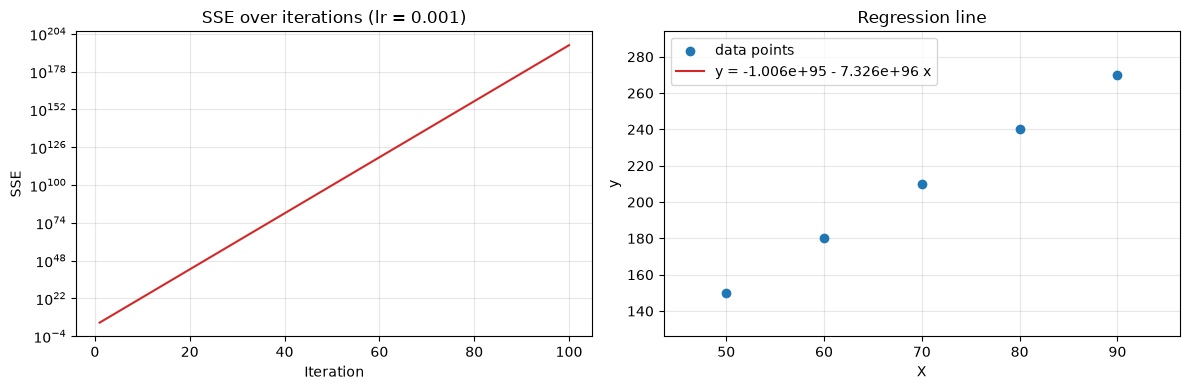

In [8]:
model.plot_training(X, y)      # lr = 0.001  -> diverged

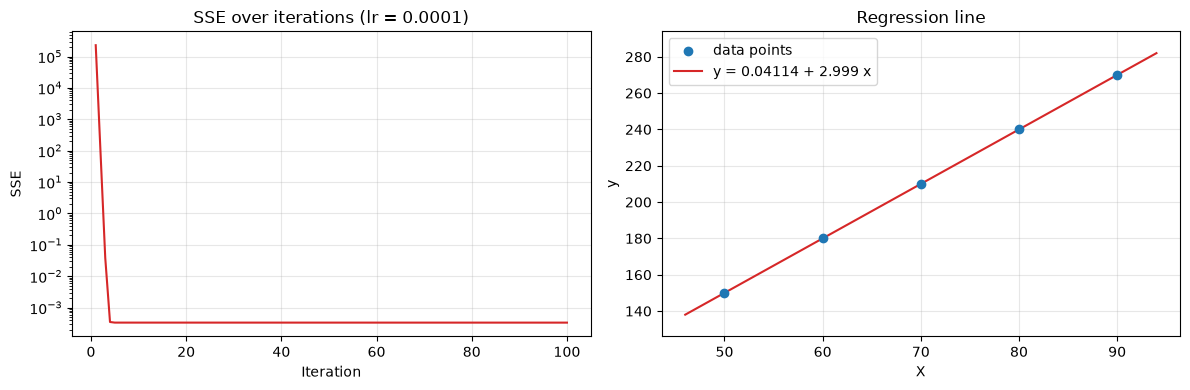

In [9]:
model_ok.plot_training(X, y)   # lr = 0.0001 -> converged

**Why does the SSE decrease over time?** (working model, lr = 0.0001)

The gradient $D_{\theta}$ points in the direction in which the cost *increases* fastest. Gradient descent
always moves the parameters in the **opposite** direction ($\theta \leftarrow \theta - \alpha D_\theta$),
so – as long as the step is not too big – every update lands at a point with a lower cost than before.
That is why the SSE curve goes down. Near the minimum the gradient becomes very small, so the steps become
tiny and the curve flattens.

**What does convergence mean in Gradient Descent?**

Convergence means the algorithm has reached (or is extremely close to) the minimum of the cost function:
the gradients are ≈ 0, the updates to $\theta_0, \theta_1$ are negligible and the SSE stops changing from
one iteration to the next – the curve becomes flat. For the working model this happens after only a few
iterations (the SSE table in the next section shows the exact numbers).

In the diverged model (lr = 0.001) the opposite happens: every step overshoots the minimum and lands
further away on the other side, so the SSE grows every iteration (the left plot needs a log scale to even
show it) and the regression line is so far off that it does not appear inside the plot at all.

## 5. Experimentation – the effect of the learning rate

I train the same model (100 iterations) with several learning rates: a very large one (0.01), the value
from the task (0.001), a slightly smaller one (0.0002), the one that worked (0.0001) and two very small
ones (1e-6 and 1e-7). For each run I record the SSE after 1, 10 and 100 iterations and the number of
iterations needed to bring the SSE below 1 (my definition of "converged" for this data).

In [10]:
def run_experiment(lr, n_iters=100):
    m = LinearRegressionGD(learning_rate=lr, n_iters=n_iters).fit(X, y)
    sse = np.array(m.sse_history)
    below_1 = np.where(sse < 1)[0]
    row = {
        "learning_rate": lr,
        "iterations run": len(sse),
        "SSE after 1 iter": sse[0],
        "SSE after 10 iters": sse[9] if len(sse) > 9 else np.nan,
        "final SSE": sse[-1],
        "iters to reach SSE < 1": int(below_1[0]) + 1 if len(below_1) else "never",
        "theta_0": m.theta_0,
        "theta_1": m.theta_1,
    }
    return row, m


learning_rates = [0.01, 0.001, 0.0002, 0.0001, 1e-6, 1e-7]
rows, models = [], {}
for lr in learning_rates:
    row, m = run_experiment(lr)
    rows.append(row)
    models[lr] = m

results = pd.DataFrame(rows).set_index("learning_rate")
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
results

Training diverged at iteration 77: SSE is no longer a finite number.


,iterations run,SSE after 1 iter,SSE after 10 iters,final SSE,iters to reach SSE < 1,theta_0,theta_1
learning_rate,,,,,,,
0.01,77,2.295e+05,2.755e+41,inf,never,-8.898e+150,-6.483e+152
0.001,100,2.295e+05,5.136e+22,1.617e+196,never,-1.006e+95,-7.326e+96
0.0002,100,2.295e+05,4.68e+05,5.823e+08,never,-2.116,-154.2
0.0001,100,2.295e+05,0.0003323,0.0003318,3,0.04114,2.999
1e-06,100,2.295e+05,1.908e+05,3.013e+04,never,0.0264,1.924
1e-07,100,2.295e+05,2.253e+05,1.875e+05,never,0.003995,0.291


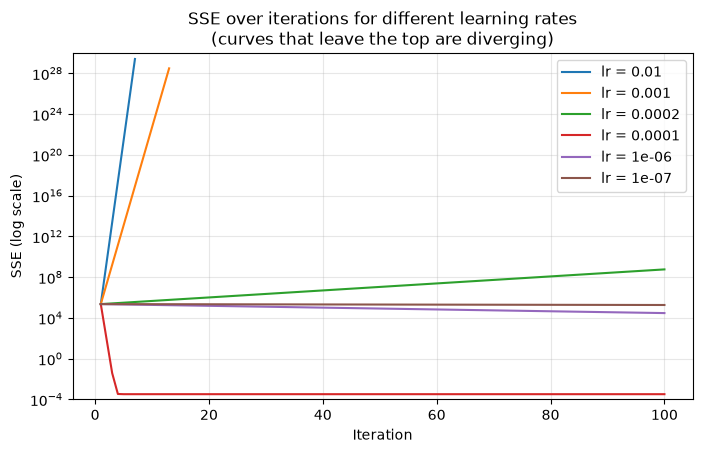

In [11]:
plt.figure(figsize=(8, 4.5))
for lr, m in models.items():
    sse = np.array(m.sse_history)
    sse = np.where(sse < 1e30, sse, np.nan)        # values beyond the plot range are not drawn
    plt.plot(np.arange(1, len(sse) + 1), sse, label=f"lr = {lr}")
plt.yscale("log")
plt.ylim(1e-4, 1e30)                               # the diverging runs shoot out of the top of the plot
plt.xlabel("Iteration")
plt.ylabel("SSE (log scale)")
plt.title("SSE over iterations for different learning rates\n(curves that leave the top are diverging)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Comparison**

| learning rate | convergence speed | final SSE after 100 iterations |
|---|---|---|
| very large (0.01, 0.001, even 0.0002) | never converges – the SSE gets **bigger** every iteration | astronomically large, or `inf` |
| good (0.0001) | very fast – SSE < 1 within a handful of iterations | ≈ 0 |
| very small (1e-6, 1e-7) | very slow – the SSE goes down, but is still huge after 100 iterations | still large |

**Question: what happens if the learning rate is too large?**

The update $\theta_1 \leftarrow \theta_1 - \alpha D_{\theta_1}$ jumps *past* the minimum to the other
side of the "bowl", and the new point has a larger error than the old one. The next gradient is therefore
bigger, the next jump is even longer, and so on: the parameters oscillate with a growing amplitude and the
cost **diverges** to infinity (with lr = 0.01 the SSE overflowed to `inf` before reaching 100 iterations).
This is what the slide *"if α is too large, gradient descent can overshoot the minima … or even diverge"* describes.

Why is 0.001 already "too large" here? Because the gradient of $\theta_1$ contains the factor $x_i$
(≈ 50–90) and the error (≈ 200 at the start), so $D_{\theta_1} \approx -3\times10^{4}$ in the first
iteration and $\theta_1$ jumps straight to ≈ 30 instead of 3. In the table you can see that the SSE is
multiplied by roughly the same factor (≈ 85) every iteration – a steady explosion.

A too-**small** learning rate does not break anything, it is just slow: with lr = 1e-7 the model moves in
the right direction, but 100 iterations are nowhere near enough. Below I show that the same tiny learning
rate does reach the solution if I give it 200× more iterations.

In [12]:
slow = LinearRegressionGD(learning_rate=1e-7, n_iters=20_000).fit(X, y)

print("lr = 1e-7 with 100 iterations    -> theta_1 = {:.4f}, SSE = {:.4g}".format(
    models[1e-7].theta_1, models[1e-7].sse_history[-1]))
print("lr = 1e-7 with 20,000 iterations -> theta_1 = {:.4f}, SSE = {:.4g}".format(
    slow.theta_1, slow.sse_history[-1]))
print("lr = 1e-4 with 100 iterations    -> theta_1 = {:.4f}, SSE = {:.4g}".format(
    model_ok.theta_1, model_ok.sse_history[-1]))

lr = 1e-7 with 100 iterations    -> theta_1 = 0.2910, SSE = 1.875e+05
lr = 1e-7 with 20,000 iterations -> theta_1 = 2.9994, SSE = 0.0003322
lr = 1e-4 with 100 iterations    -> theta_1 = 2.9994, SSE = 0.0003318


## 6. Bonus tasks

### 6.1 MSE method

I already added `mse()` to the class. MSE is the *mean* of the squared errors, so it is simply the SSE
divided by $n$ (Linear Regression lecture, slide 16):

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2 = \frac{SSE}{n}$$

In [13]:
sse_final = np.sum((model_ok.predict(X) - y) ** 2)

print(f"SSE with the final parameters : {sse_final:.6f}")
print(f"SSE / n                       : {sse_final / len(X):.6f}")
print(f"mse() method                  : {model_ok.mse(X, y):.6f}")
print(f"RMSE (same unit as the price) : {np.sqrt(model_ok.mse(X, y)):.4f}")
print(f"MSE of the diverged model     : {model.mse(X, y):.4g}")

SSE with the final parameters : 0.000332
SSE / n                       : 0.000066
mse() method                  : 0.000066
RMSE (same unit as the price) : 0.0081
MSE of the diverged model     : 2.739e+197


### 6.2 Normalize X before training

The divergence problem came from the scale of X (50–90). Here I scale X to the range [0, 1] with
**min-max normalization** (the same idea as `MinMaxScaler` from the session-1 practice, done by hand
with numpy):

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Then I train with the learning rate from the task (0.001) and with much bigger ones (0.1 and 0.5), and
compare with the results on the raw X. Important: the model now learns in "normalized units", so to predict
the price of a 70 m² house I must normalize 70 with the **same** min and max that were used for training
(this is the "fit on training data, only transform at prediction time" rule from the session-1 practice).

In [14]:
X_min, X_max = X.min(), X.max()

def normalize(x):
    return (x - X_min) / (X_max - X_min)

X_norm = normalize(X)
print("X_norm:", X_norm)

rows = []
for lr in [0.001, 0.1, 0.5]:
    m = LinearRegressionGD(learning_rate=lr, n_iters=100).fit(X_norm, y)
    rows.append({"learning_rate": lr,
                 "theta_0": m.theta_0, "theta_1": m.theta_1,
                 "final SSE": m.sse_history[-1],
                 "prediction for 70 m²": float(m.predict(normalize(70)))})
    if lr == 0.5:
        model_norm = m

pd.DataFrame(rows).set_index("learning_rate")

X_norm: [0.   0.25 0.5  0.75 1.  ]


,theta_0,theta_1,final SSE,prediction for 70 m²
learning_rate,,,,
0.001,37.07,21.26,1.385e+05,47.71
0.1,152.2,116.1,10.15,210.2
0.5,150,120,7.066e-07,210


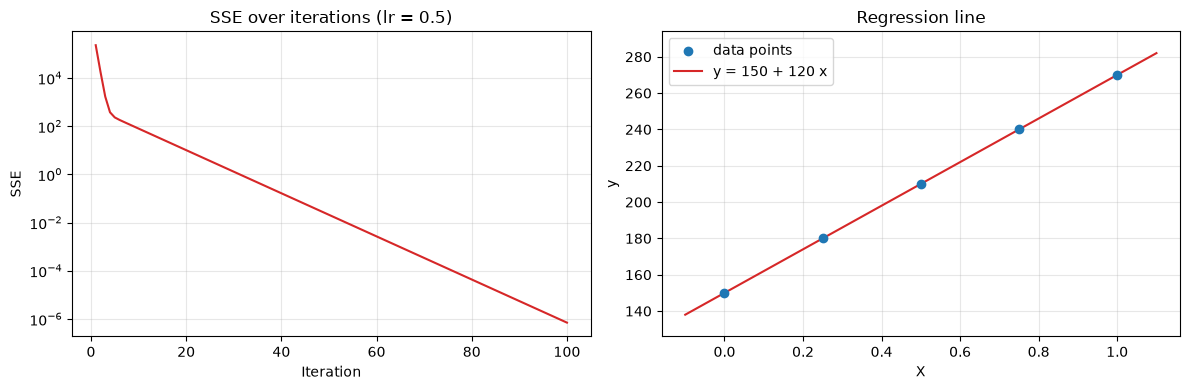

In [15]:
model_norm.plot_training(X_norm, y)   # trained on normalized X with lr = 0.5

**Comparison – raw X vs normalized X**

- With raw X the learning rate had to be smaller than about 0.0002, otherwise training exploded. With
  normalized X even lr = 0.5 is stable, and lr = 0.001 is now actually *too small* (the SSE is still large
  after 100 iterations). Normalization makes the choice of the learning rate much less sensitive to the
  scale of the feature.
- The learned parameters look different ($\theta_0 \approx 150$, $\theta_1 \approx 120$) because they are
  in normalized units: $\theta_0$ is the price of the smallest house ($x_{norm} = 0$ → 50 m² → 150) and
  $\theta_1$ is the price increase over the whole range (40 m² × 3 = 120). The **predictions are the same**
  (70 m² → 210).
- Both approaches reach ≈ 0 SSE when the learning rate is chosen well; normalization just makes it much
  easier to find a good one.

### 6.3 Multiple features

To support more than one feature I rewrite the class with vectors instead of two separate numbers. With a
column of ones added to X (so that the bias is just another weight) the model and the gradient become

$$\hat{y} = X_b\,\theta, \qquad D_\theta = \frac{2}{n} X_b^{T}(\hat{y} - y), \qquad \theta \leftarrow \theta - \alpha D_\theta$$

where $\theta = [\theta_0, \theta_1, \dots, \theta_k]$. With one feature this is exactly the same math as
before; with more features it is the multiple linear regression from slide 13 of the ML Session 1 lecture
($y = b_0 + b_1x_1 + b_2x_2 + \dots$).

In [16]:
class MultipleLinearRegressionGD:
    """Linear regression with any number of features, trained with batch Gradient Descent.

    Model    : y_pred = theta_0 + theta_1*x1 + theta_2*x2 + ...  =  X_b @ theta
               (X_b is X with a column of ones in front, for the intercept)
    Gradient : (2/n) * X_b.T @ (y_pred - y)
    """

    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta = None
        self.sse_history = []

    @staticmethod
    def _add_bias_column(X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:                       # a single feature given as a 1-D array
            X = X.reshape(-1, 1)
        return np.c_[np.ones(len(X)), X]

    def fit(self, X, y):
        X_b = self._add_bias_column(X)
        y = np.asarray(y, dtype=float)
        n = len(y)
        self.theta = np.zeros(X_b.shape[1])
        self.sse_history = []

        for i in range(self.n_iters):
            error = X_b @ self.theta - y
            sse = np.sum(error ** 2)
            self.sse_history.append(sse)
            if not np.isfinite(sse):
                print(f"Training diverged at iteration {i + 1}.")
                break
            gradient = (2 / n) * X_b.T @ error
            self.theta -= self.learning_rate * gradient
        return self

    def predict(self, X):
        return self._add_bias_column(X) @ self.theta

    def mse(self, X, y):
        return np.mean((self.predict(X) - np.asarray(y, dtype=float)) ** 2)

    def plot_training(self):
        plt.figure(figsize=(6, 4))
        plt.plot(np.arange(1, len(self.sse_history) + 1), self.sse_history, color="tab:red")
        plt.yscale("log")
        plt.xlabel("Iteration")
        plt.ylabel("SSE (log scale)")
        plt.title(f"SSE over iterations (lr = {self.learning_rate})")
        plt.grid(alpha=0.3)
        plt.show()

In [17]:
# Check 1: one feature -> must give the same result as LinearRegressionGD
multi_1 = MultipleLinearRegressionGD(learning_rate=0.0001, n_iters=100).fit(X, y)
print("MultipleLinearRegressionGD theta :", multi_1.theta)
print("LinearRegressionGD (model_ok)    :", np.array([model_ok.theta_0, model_ok.theta_1]))
print("Same result?", np.allclose(multi_1.theta, [model_ok.theta_0, model_ok.theta_1]))

MultipleLinearRegressionGD theta : [0.04113676 2.99943537]
LinearRegressionGD (model_ok)    : [0.04113676 2.99943537]
Same result? True


y2: [170. 220. 250. 300. 330.]
theta (normalized units): [170. 120.  40.]
MSE on the training data: 0.000000
predictions vs real     : [170. 220. 250. 300. 330.] vs [170. 220. 250. 300. 330.]
prediction for 75 m² / 2 rooms: 265.00 | expected 3*75 + 20*2 = 265


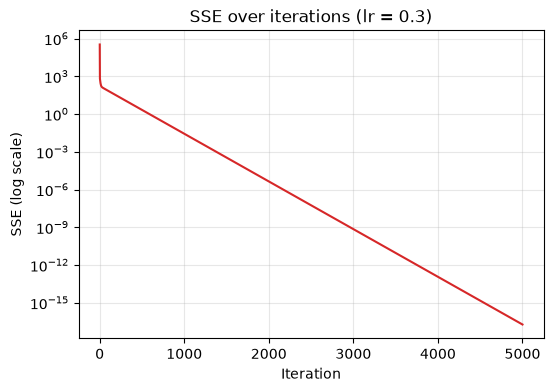

In [18]:
# Check 2: two features -> size (m²) and number of rooms
X2 = np.array([[50, 1],
               [60, 2],
               [70, 2],
               [80, 3],
               [90, 3]], dtype=float)
y2 = 3 * X2[:, 0] + 20 * X2[:, 1]        # price = 3*size + 20*rooms  (no noise)
print("y2:", y2)

# normalize every column with its own min/max (same idea as 6.2)
col_min, col_max = X2.min(axis=0), X2.max(axis=0)
def normalize_2(X):
    return (np.asarray(X, dtype=float) - col_min) / (col_max - col_min)

multi_2 = MultipleLinearRegressionGD(learning_rate=0.3, n_iters=5000).fit(normalize_2(X2), y2)

print("theta (normalized units):", np.round(multi_2.theta, 4))
print("MSE on the training data:", f"{multi_2.mse(normalize_2(X2), y2):.6f}")
print("predictions vs real     :", np.round(multi_2.predict(normalize_2(X2)), 2), "vs", y2)

new_house = [[75, 2]]                                       # 75 m², 2 rooms
print("prediction for 75 m² / 2 rooms:", f"{float(multi_2.predict(normalize_2(new_house))[0]):.2f}",
      "| expected 3*75 + 20*2 =", 3 * 75 + 20 * 2)
multi_2.plot_training()

Check 1 – with a single feature the new class gives the same $\theta_0, \theta_1$ as `LinearRegressionGD`,
so the vectorized formulas are right.

Check 2 – with two features (size and number of rooms, prices generated as `3·size + 20·rooms`) the model
fits the training data with ≈ 0 error and predicts the new house correctly. Because the two features have
very different scales (50–90 vs 1–3) I normalized each column first, exactly like in 6.2.

## Summary – what I learned

- **Gradient descent** = start with any $\theta$, compute the gradient of the cost, take a small step
  against it, repeat. The learning rate decides the step size.
- The learning rate is not "one size fits all": with raw house sizes 0.001 explodes, with normalized sizes
  0.001 is too slow and 0.5 is perfect. **Scaling the features** makes gradient descent much better behaved.
- Too large $\alpha$ → overshoot and divergence (SSE grows). Too small $\alpha$ → converges, but needs many
  more iterations. The right $\alpha$ → the SSE drops quickly and then flattens (convergence).
- Writing the model as a class (`fit`, `predict`, `mse`, `plot_training`) keeps the code organised and makes
  it easy to run many experiments – the same idea as the scikit-learn API.
- Everything here was done with numpy + matplotlib only, no scikit-learn.